In [16]:
import os
from bs4 import BeautifulSoup
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Paths
resume_file = "resume.txt"
job_folder = "job_postings"

In [17]:
with open(resume_file, "r", encoding="utf-8") as f:
    resume_text = f.read()

print("Resume preview:\n")
print(resume_text[:300])

Resume preview:

Experience

1. Developed probability simulations using NumPy.
2. Assessed online ad-clicks for statistical significance using Permutation testing.
3. Analyzed disease outbreaks using common clustering algorithms.

Additional Skills

1. Data visualization using Matplotlib.
2. Statistical analysis usi


In [18]:
all_postings = []

for filename in os.listdir(job_folder):
    if filename.endswith(".html"):
        with open(os.path.join(job_folder, filename), "r", encoding="utf-8") as f:
            soup = BeautifulSoup(f, "html.parser")
            text = soup.get_text(" ", strip=True)
            all_postings.append(text)

print(f"Loaded {len(all_postings)} postings")
print("\nExample posting:\n", all_postings[0][:500])

Loaded 1458 postings

Example posting:
 Data Scientist - Beavercreek, OH Data Scientist - Beavercreek, OH Data Scientist Position Overview: Centauri is looking for a detail oriented, motivated, and organized Data Scientist to work as part of a team to clean, analyze, and produce insightful reporting on government data. The ideal candidate is adept at using large data sets to find trends for intelligence reporting and will be proficient in process optimization and using models to test the effectiveness of different courses of action. T


In [31]:
documents = [resume_text] + all_postings
vectorizer = TfidfVectorizer(stop_words="english")
X = vectorizer.fit_transform(documents)

similarities = cosine_similarity(X[0:1], X[1:]).flatten()

threshold = 0.04  # you can adjust this
relevant_postings = [p for p, sim in zip(all_postings, similarities) if sim > threshold]

print(f"Relevant postings: {len(relevant_postings)} / {len(all_postings)}")

Relevant postings: 486 / 1458


In [27]:
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter

# Use n-grams (1 to 3 words) to capture skills/phrases
vectorizer = CountVectorizer(ngram_range=(1, 3), stop_words="english", min_df=3)
X_counts = vectorizer.fit_transform(relevant_postings)

# Get all terms with their frequencies
sum_words = X_counts.sum(axis=0)
words_freq = [(word, int(sum_words[0, idx])) for word, idx in vectorizer.vocabulary_.items()]

# Sort by frequency
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

# Extract phrases that appear at least 5 times
extracted_skills = [w for w, f in words_freq if f >= 5]

print("Number of extracted skill phrases:", len(extracted_skills))
print("\nTop 30 automatically extracted skill phrases:\n")
for phrase, freq in words_freq[:30]:
    print(f"{phrase} ({freq})")

Number of extracted skill phrases: 31722

Top 30 automatically extracted skill phrases:

data (12289)
experience (6823)
work (3758)
business (3028)
learning (2870)
team (2806)
analysis (2758)
skills (2642)
science (2572)
ability (2183)
machine (2154)
research (2092)
machine learning (2041)
analytics (1890)
knowledge (1846)
development (1699)
including (1695)
new (1676)
engineering (1657)
years (1652)
information (1615)
statistical (1608)
using (1596)
working (1582)
management (1561)
ca (1553)
scientist (1525)
tools (1491)
models (1459)
software (1450)


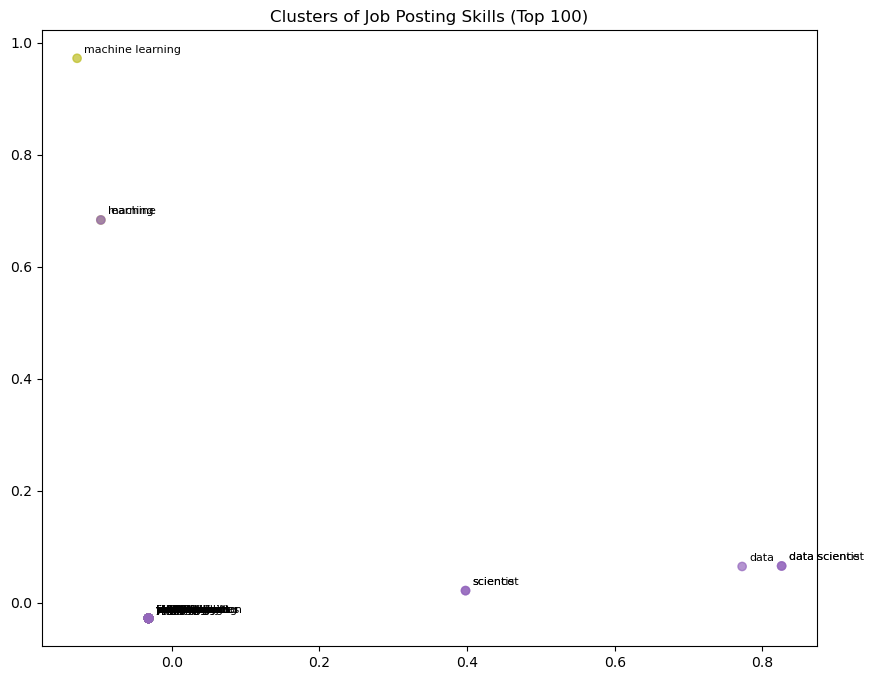

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Limit to top N skills for readability
top_n = 100  
skills_for_clustering = extracted_skills[:top_n]

vectorizer = TfidfVectorizer()
X_skills = vectorizer.fit_transform(skills_for_clustering)

# Cluster into 5 groups (tune n_clusters as needed)
kmeans = KMeans(n_clusters=10, random_state=42).fit(X_skills)
labels = kmeans.labels_

# Reduce to 2D for visualization
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_skills.toarray())

plt.figure(figsize=(10, 8))
plt.scatter(coords[:,0], coords[:,1], c=labels, cmap="tab10", alpha=0.7)

for i, skill in enumerate(skills_for_clustering):
    plt.text(coords[i,0]+0.01, coords[i,1]+0.01, skill, fontsize=8)

plt.title("Clusters of Job Posting Skills (Top 100)")
plt.show()

In [33]:
missing_skills = []
resume_lower = resume_text.lower()

for skill in set(extracted_skills):
    if skill.lower() not in resume_lower:
        missing_skills.append(skill)

print("Number of missing skills:", len(missing_skills))
print("\nSample missing skills:\n", missing_skills[:30])


Number of missing skills: 31560

Sample missing skills:
 ['foley insertion', 'directing', 'relevant building analytic', 'position supervisory', 'apis platforms', 'data ingestion', '000 people', 'text data', 'washington', 'fault detection', 'projects support', 'media entertainment', 'solutions drive', 'technical knowledge attending', 'exciting career', 'professor', 'ability multi', 'using quantitative', 'carry push pull', 'given data', 'instructors teaching assistants', 'recall', 'execute product decisions', 'kept confidential according', 'customer data', 'teams support', 'deliverables presentations', 'ideas want', 'projects ensure', 'warning']


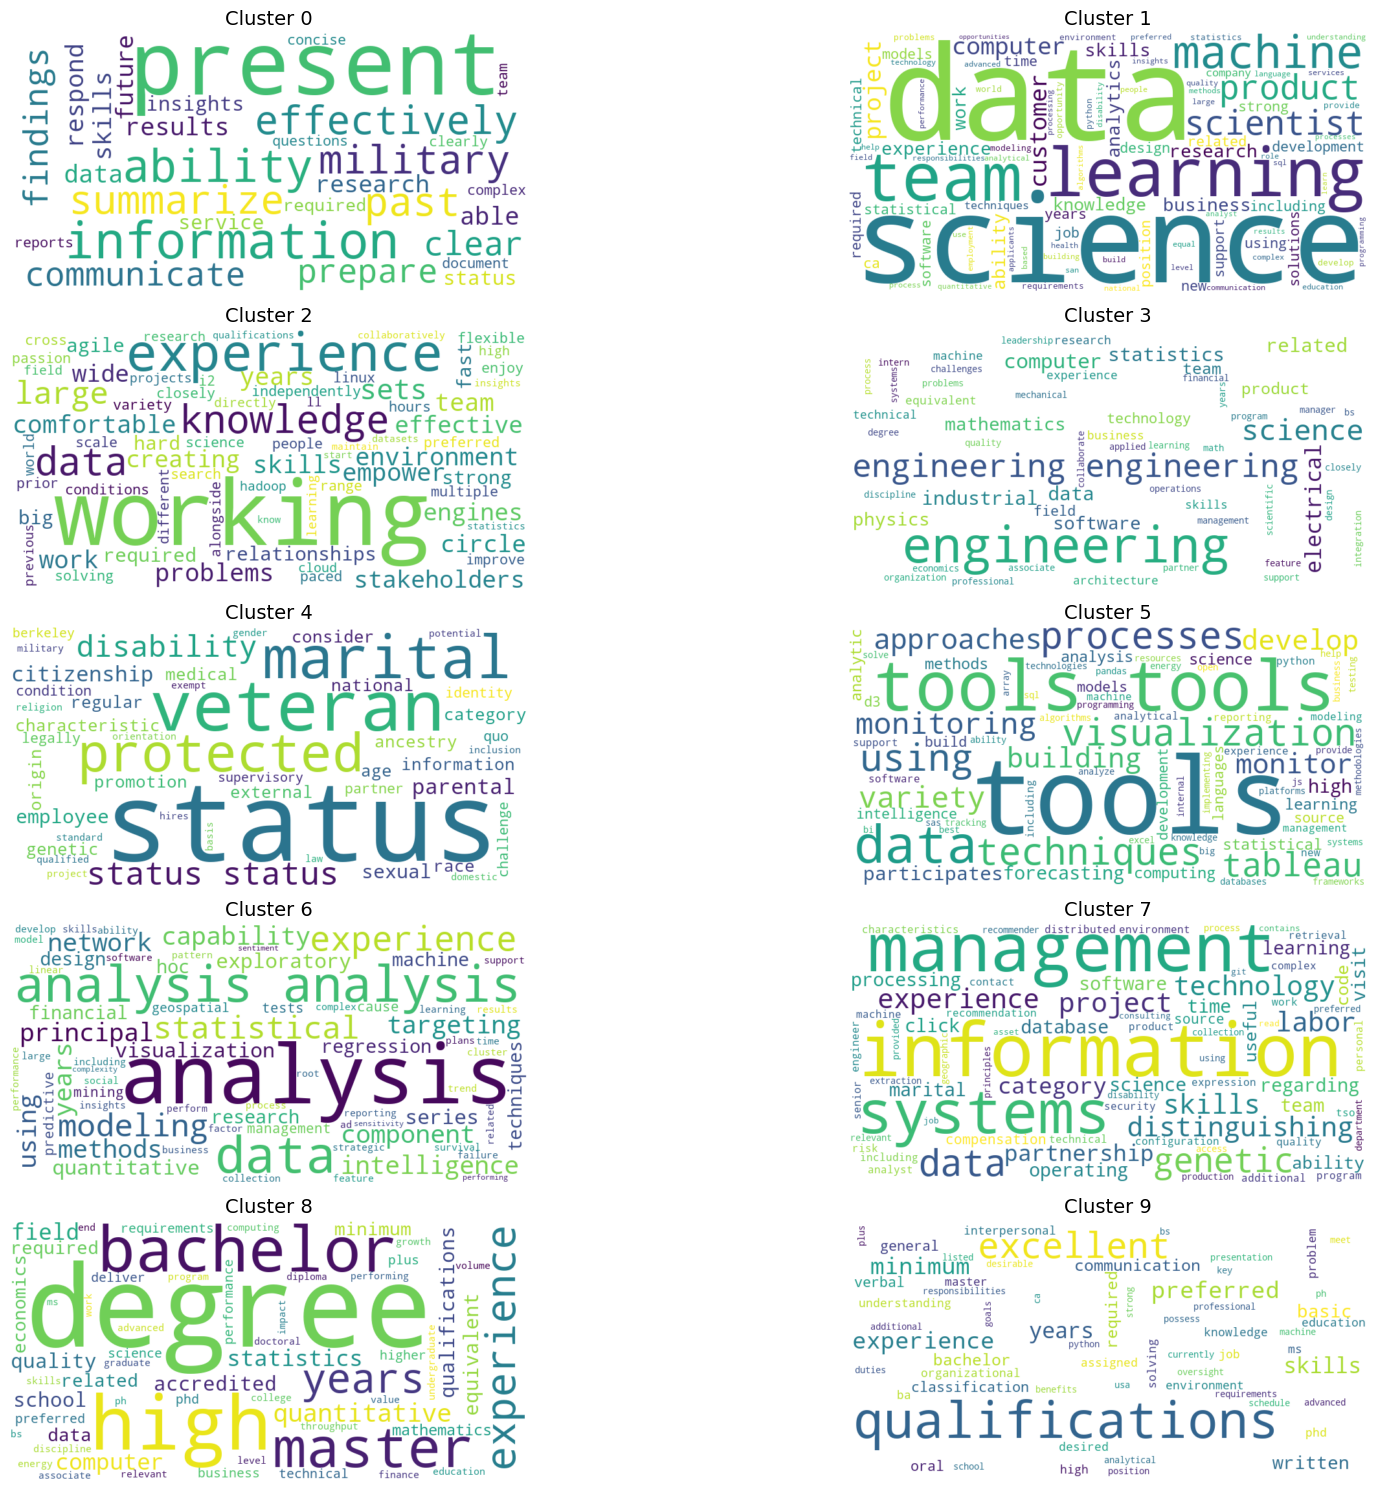

In [38]:
from wordcloud import WordCloud
import math

vectorizer = TfidfVectorizer()
X_skills = vectorizer.fit_transform(extracted_skills)

n_clusters = 10
kmeans = KMeans(n_clusters=n_clusters, random_state=42).fit(X_skills)
labels = kmeans.labels_

clusters = {}
for skill, label in zip(extracted_skills, labels):
    clusters.setdefault(label, []).append(skill)

# Plot wordclouds in a 3x4 grid
fig, axes = plt.subplots(5, 2, figsize=(20, 15))  # 3 rows, 4 columns
axes = axes.flatten()

for cluster_id in range(10):  # fill all 12 slots
    ax = axes[cluster_id]
    if cluster_id in clusters:
        text = " ".join(clusters[cluster_id][:100])  # limit to top 100 skills
        wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)
        ax.imshow(wordcloud, interpolation="bilinear")
        ax.set_title(f"Cluster {cluster_id}", fontsize=14)
        ax.axis("off")
    else:
        ax.axis("off")  # empty slot

plt.tight_layout()
plt.show()